In [1]:
#GAN implementation for MNIST using PyTorch

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#Set Device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
#Load MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

dataloader = DataLoader(train_data, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.56MB/s]


In [5]:
#Define Generator
class Generator(nn.Module):
    def __init__(self, noise_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [6]:
#Define Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [7]:
#Initialize Models
noise_dim = 100

G = Generator(noise_dim).to(device)
D = Discriminator().to(device)

In [8]:
#Loss & Optimizers
criterion = nn.BCELoss()

lr = 0.0002

optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

In [10]:
#Training Loop
epochs = 20

for epoch in range(epochs):
    for real_imgs, _ in dataloader:

        batch_size = real_imgs.size(0)

        # Flatten images
        real_imgs = real_imgs.view(batch_size, -1).to(device)

        # Real and fake labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # =========================
        # Train Discriminator
        # =========================
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = G(noise)

        real_loss = criterion(D(real_imgs), real_labels)
        fake_loss = criterion(D(fake_imgs.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # =========================
        # Train Generator
        # =========================
        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = G(noise)

        g_loss = criterion(D(fake_imgs), real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  D Loss: {d_loss.item():.4f}  G Loss: {g_loss.item():.4f}")

Epoch [1/20]  D Loss: 0.1479  G Loss: 5.4264
Epoch [2/20]  D Loss: 0.6092  G Loss: 1.8088
Epoch [3/20]  D Loss: 1.1292  G Loss: 2.3982
Epoch [4/20]  D Loss: 0.4304  G Loss: 4.3621
Epoch [5/20]  D Loss: 0.0956  G Loss: 3.9989
Epoch [6/20]  D Loss: 0.2679  G Loss: 4.0944
Epoch [7/20]  D Loss: 0.0985  G Loss: 3.8672
Epoch [8/20]  D Loss: 0.6065  G Loss: 5.0440
Epoch [9/20]  D Loss: 0.7177  G Loss: 4.0876
Epoch [10/20]  D Loss: 0.9928  G Loss: 4.0606
Epoch [11/20]  D Loss: 0.1354  G Loss: 5.6505
Epoch [12/20]  D Loss: 0.3024  G Loss: 5.2386
Epoch [13/20]  D Loss: 0.2315  G Loss: 3.8308
Epoch [14/20]  D Loss: 0.3232  G Loss: 3.2930
Epoch [15/20]  D Loss: 0.0813  G Loss: 4.1789
Epoch [16/20]  D Loss: 0.2476  G Loss: 3.5718
Epoch [17/20]  D Loss: 0.4519  G Loss: 4.0074
Epoch [18/20]  D Loss: 0.5917  G Loss: 4.2408
Epoch [19/20]  D Loss: 0.1581  G Loss: 5.0686
Epoch [20/20]  D Loss: 0.2704  G Loss: 3.6083


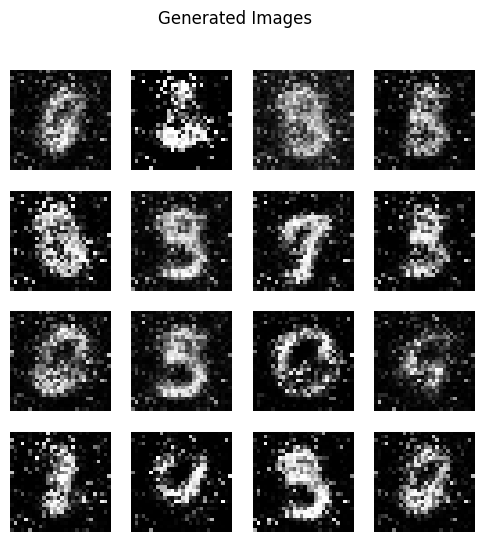

In [11]:
# Generate Fake Images
def show_images(images, title="Generated Images"):
    images = images.detach().cpu().view(-1, 28, 28)

    plt.figure(figsize=(6,6))
    for i in range(16):
        plt.subplot(4,4,i+1)
        plt.imshow(images[i], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()


noise = torch.randn(16, noise_dim).to(device)
generated = G(noise)

show_images(generated)

In [ ]:
-